<a href="https://colab.research.google.com/github/khushi-mahida/BASCIS_DATASCI_MACHINE-LEARNING-/blob/main/arima_sales_forcasting_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np


In [ ]:
np.random.seed(35)

In [ ]:
dates=pd.date_range(start= '3/4/2002',periods= 100)

In [ ]:
print (dates)

DatetimeIndex(['2002-03-04', '2002-03-05', '2002-03-06', '2002-03-07',
               '2002-03-08', '2002-03-09', '2002-03-10', '2002-03-11',
               '2002-03-12', '2002-03-13', '2002-03-14', '2002-03-15',
               '2002-03-16', '2002-03-17', '2002-03-18', '2002-03-19',
               '2002-03-20', '2002-03-21', '2002-03-22', '2002-03-23',
               '2002-03-24', '2002-03-25', '2002-03-26', '2002-03-27',
               '2002-03-28', '2002-03-29', '2002-03-30', '2002-03-31',
               '2002-04-01', '2002-04-02', '2002-04-03', '2002-04-04',
               '2002-04-05', '2002-04-06', '2002-04-07', '2002-04-08',
               '2002-04-09', '2002-04-10', '2002-04-11', '2002-04-12',
               '2002-04-13', '2002-04-14', '2002-04-15', '2002-04-16',
               '2002-04-17', '2002-04-18', '2002-04-19', '2002-04-20',
               '2002-04-21', '2002-04-22', '2002-04-23', '2002-04-24',
               '2002-04-25', '2002-04-26', '2002-04-27', '2002-04-28',
      

In [ ]:
sales = np.linspace(50,200,num=100)
print (sales)

[ 50.          51.51515152  53.03030303  54.54545455  56.06060606
  57.57575758  59.09090909  60.60606061  62.12121212  63.63636364
  65.15151515  66.66666667  68.18181818  69.6969697   71.21212121
  72.72727273  74.24242424  75.75757576  77.27272727  78.78787879
  80.3030303   81.81818182  83.33333333  84.84848485  86.36363636
  87.87878788  89.39393939  90.90909091  92.42424242  93.93939394
  95.45454545  96.96969697  98.48484848 100.         101.51515152
 103.03030303 104.54545455 106.06060606 107.57575758 109.09090909
 110.60606061 112.12121212 113.63636364 115.15151515 116.66666667
 118.18181818 119.6969697  121.21212121 122.72727273 124.24242424
 125.75757576 127.27272727 128.78787879 130.3030303  131.81818182
 133.33333333 134.84848485 136.36363636 137.87878788 139.39393939
 140.90909091 142.42424242 143.93939394 145.45454545 146.96969697
 148.48484848 150.         151.51515152 153.03030303 154.54545455
 156.06060606 157.57575758 159.09090909 160.60606061 162.12121212
 163.63636

In [ ]:
sales += np.random.normal(0,10,size=sales.shape)
print (sales)

[ 29.0841151   37.09609028  50.24247971  51.58011441  59.24377934
  53.51984528  65.50321542  46.97971179  68.99738134  53.17836812
  78.60162815  74.11861379  60.03390884  71.90139947  68.97921559
  79.25807321  88.18159257  80.48209265  84.51324823  97.06043039
  76.44976262  94.55765151  76.0662029   74.29333     78.49981952
  78.30917178 100.87232819 109.16700306 112.35885962 102.45887638
  91.31810282  90.30608074 102.55871242 100.03740236 120.750298
 109.48236391 109.43042259 115.89126234 103.80520474 110.13109879
 103.24047103 106.48951293 113.99744585 116.27171699 118.4354182
 125.73705897 111.81419182 124.12795908 127.72686645 117.6346647
 118.03264582 128.10326503 145.44511193 136.27460416 140.23907046
 143.53981951 128.58899823 148.70781272 135.86237147 143.4538269
 129.20914507 149.89467023 151.68392125 141.06032154 141.91353707
 133.17665014 169.54963134 152.76428819 140.88429041 150.82417595
 158.29365502 182.05391103 164.25905677 168.58531554 177.942041
 163.09597202 168

In [ ]:
 data = pd.DataFrame({'date':dates,'sales':sales})
 print(data)

         date       sales
0  2002-03-04   29.084115
1  2002-03-05   37.096090
2  2002-03-06   50.242480
3  2002-03-07   51.580114
4  2002-03-08   59.243779
..        ...         ...
95 2002-06-07  203.014160
96 2002-06-08  186.399111
97 2002-06-09  194.215637
98 2002-06-10  210.865634
99 2002-06-11  172.111337

[100 rows x 2 columns]


In [ ]:
import plotly.express as px

In [ ]:
fig = px.line(data,x='date',y='sales')
fig.update_layout(title='Sales Over Time',xaxis_title='Date',yaxis_title='Sales')
fig.show()

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error,mean_squared_error


In [ ]:
train_size= int(len(data)*0.8)
train,test= data['sales'][:train_size],data['sales'][train_size:]

In [ ]:
model = ARIMA(train,order=(1,3,4))
model_fit = model.fit()


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning:

Non-invertible starting MA parameters found. Using zeros as starting parameters.



In [ ]:
predictions =  model_fit.forecast(steps = len(test))

mae = mean_absolute_error(test,predictions)
mse = mean_squared_error(test,predictions)

In [ ]:
print (f'Mean Absolute Error: {mae}')
print (f'Mean Squared Error: {mse}')


Mean Absolute Error: 24.344060744047887
Mean Squared Error: 764.9685417948016


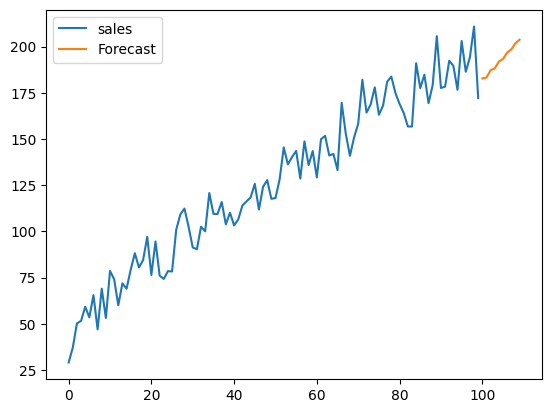

In [ ]:

#Predictions

# The ARIMA model can be used to make predictions on future values of the time series
# The forecast method is used to predict future values
# The steps parameter specifies the number of steps ahead to forecast

# here we  will forecast the next 10 values in the time series

forecast = model_fit.forecast(steps=10)

plt.plot(data['sales'], label='sales')
plt.plot(range(len(data), len(data)+10), forecast, label='Forecast')
plt.legend()
plt.show()



In [ ]:
#  Model Tuning
import itertools
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error
import pandas as pd

# Define the p, d, q parameters to take any value between 0 and 4
p = d = q = range(0, 5)

# Generate all different combinations of p, d and q triplets
pdq = list(itertools.product(p, d, q))

# Initialize a DataFrame to store the results
results = pd.DataFrame(columns=['pdq', 'MAE'])

# Grid search for the best ARIMA parameters
for param in pdq:
    try:
        model = ARIMA(train, order=param)
        model_fit = model.fit()
        predictions = model_fit.forecast(steps=len(test))
        mae = mean_absolute_error(test, predictions)
        results = pd.concat([results, pd.DataFrame({'pdq': [param], 'MAE': [mae]})], ignore_index=True)
    except Exception as e:
        print(f"Error for parameters {param}: {e}")
        if hasattr(e, 'mle_retvals'):
            print(f"MLE return values: {e.mle_retvals}")

# Check if results DataFrame is empty
if results.empty:
    print("No valid ARIMA parameters found.")
else:
    # Find the best parameters
    best_params = results.loc[results['MAE'].idxmin()]
    print(f"Best ARIMA parameters: {best_params['pdq']}")
    print(f"Best MAE: {best_params['MAE']}")




/tmp/ipykernel_12226/2826331765.py:23: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning:

Non-invertible starting MA parameters found. Using zeros as starting parameters.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning:

Non-invertible starting MA parameters found. Using zeros as starting parameters.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning:

Non-invertible starting MA parameters found. Us

Error for parameters (2, 4, 3): LU decomposition error.


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning:

Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning:

Non-invertible starting MA parameters found. Using zeros as starting parameters.

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning:

Non-stationary starting autoregressive param

Error for parameters (4, 2, 4): LU decomposition error.


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning:

Non-invertible starting MA parameters found. Using zeros as starting parameters.

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning:

Non-invertible starting MA parameters found. Using zeros as starting parameters.

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning:

Non-invertible starting MA parameters found. Using zeros as starting parameters.

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to con

Best ARIMA parameters: (4, 2, 0)
Best MAE: 11.263357558310256


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



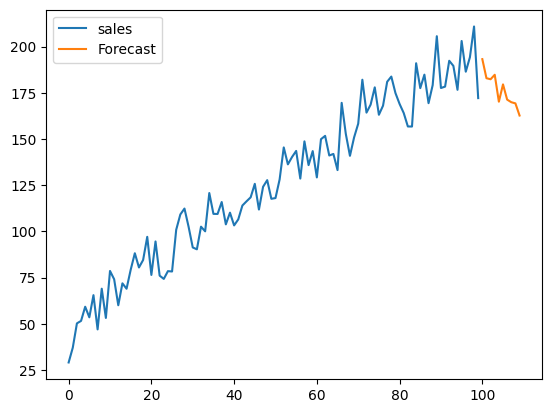

In [ ]:

# Forecasting with Best Parameters ------------------
# Fit the ARIMA model with the best parameters
model = ARIMA(data['sales'], order=best_params['pdq'])
model_fit = model.fit()

# Forecast the next 10 values
forecast = model_fit.forecast(steps=10)

plt.plot(data['sales'], label='sales')
plt.plot(range(len(data), len(data)+10), forecast, label='Forecast')
plt.legend()
plt.show()